In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

results = {}

for name, thresh in thresholds.items():
    y_alt = (df["crude_rate"] >= thresh).astype(int)

    # Use same train/test split (group-based on FIPS) so results are comparable
    y_train_alt = y_alt.iloc[train_idx]
    y_test_alt  = y_alt.iloc[test_idx]

    # Skip if class imbalance is extreme (one class < 5% in train)
    if y_train_alt.mean() < 0.05 or y_train_alt.mean() > 0.95:
        continue

    pipe_alt = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="elasticnet", solver="saga",
            C=0.1, l1_ratio=0.9, max_iter=5000,
            class_weight="balanced", random_state=42
        ))
    ])
    pipe_alt.fit(X_train, y_train_alt)

    coef = pipe_alt.named_steps["clf"].coef_[0]
    top5 = pd.Series(np.abs(coef), index=feature_cols_model).nlargest(5).index.tolist()
    results[name] = top5

# Print results
print("Top 5 features by threshold choice:\n")
for name, top5 in results.items():
    print(f"{name}:")
    for f in top5:
        print(f"  - {f}")
    print()

# Find features that appear in every top 5
common = set.intersection(*[set(v) for v in results.values()])
print(f"Features in TOP 5 across ALL thresholds: {common}")

Top 5 features by threshold choice:

Unweighted median (current):
  - svi_minority
  - svi_age65_plus
  - population
  - RPL_THEME4
  - svi_age17_under

Population-weighted median:
  - svi_minority
  - svi_age65_plus
  - svi_limited_english
  - svi_age17_under
  - acs_median_income

CDC national rate (~13.6):
  - svi_minority
  - svi_age65_plus
  - svi_limited_english
  - svi_age17_under
  - acs_median_income

Top quartile (75th pct):
  - population
  - svi_minority
  - svi_age65_plus
  - RPL_THEME4
  - svi_age17_under

Features in TOP 5 across ALL thresholds: {'svi_age17_under', 'svi_age65_plus', 'svi_minority'}


In [26]:
# Fix: population is leaky (deaths/population*100k = crude_rate)
feature_cols_fixed = [col for col in feature_cols_model if col != "population"]

X_fixed = df[feature_cols_fixed].copy()
y_fixed = (df["violence_level"] == "high").astype(int)

gss_fixed = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx_f, test_idx_f = next(gss_fixed.split(X_fixed, y_fixed, groups))

X_train_f, X_test_f = X_fixed.iloc[train_idx_f], X_fixed.iloc[test_idx_f]
y_train_f, y_test_f = y_fixed.iloc[train_idx_f], y_fixed.iloc[test_idx_f]

# Reuse best params from grid search
pipe_fixed = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=5000,
        random_state=42,
        C=grid.best_params_["clf__C"],
        l1_ratio=grid.best_params_["clf__l1_ratio"]
    ))
])
pipe_fixed.fit(X_train_f, y_train_f)

y_pred_f  = pipe_fixed.predict(X_test_f)
y_proba_f = pipe_fixed.predict_proba(X_test_f)[:,1]

train_pred_f = pipe_fixed.predict(X_train_f)

print("=== FIXED Elastic Net LR (population removed) ===")
print

=== FIXED Elastic Net LR (population removed) ===


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

                Model  Train Acc  Test Acc    Gap     F1  ROC-AUC
     Original (leaky)     0.7544    0.7423 0.0121 0.7371   0.8197
Fixed (no population)     0.7488    0.7367 0.0121 0.7299   0.8147


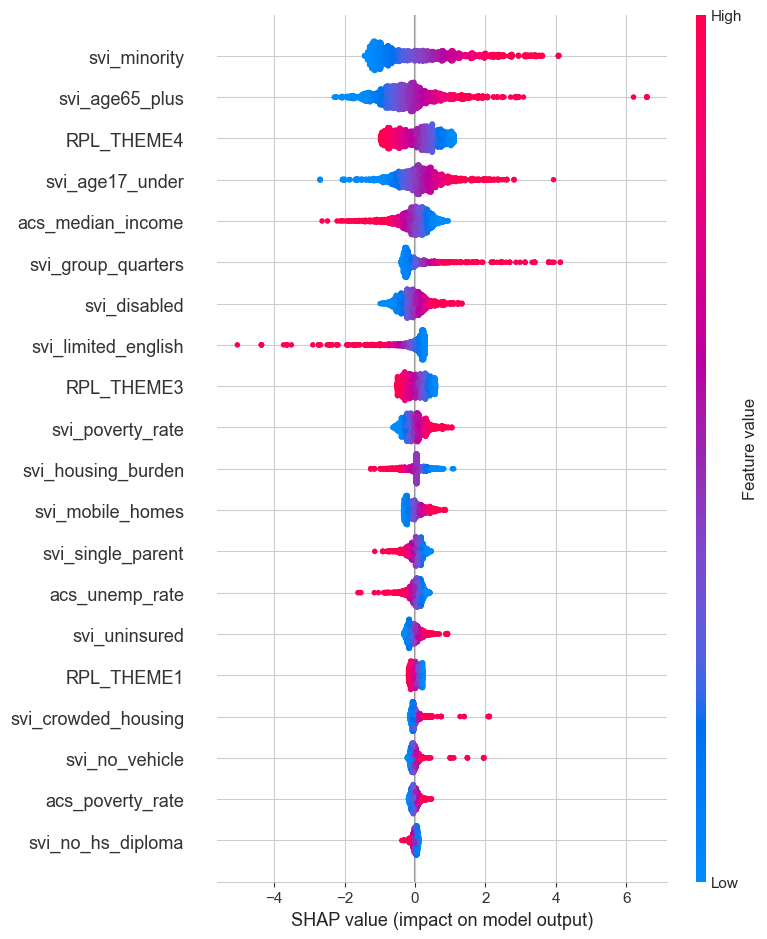

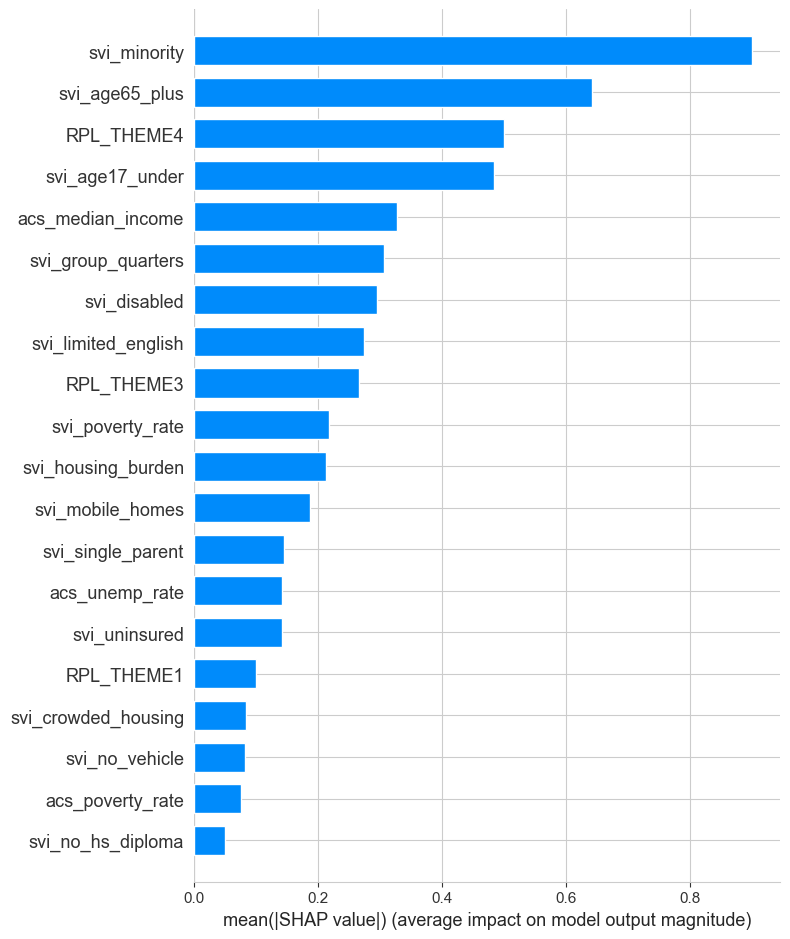

In [27]:
# Comparison table
comparison_table = pd.DataFrame({
    "Model":      ["Original (leaky)", "Fixed (no population)"],
    "Train Acc":  [best_model.score(X_train, y_train), pipe_fixed.score(X_train_f, y_train_f)],
    "Test Acc":   [accuracy_score(y_test, y_pred),     accuracy_score(y_test_f, y_pred_f)],
    "Gap":        [best_model.score(X_train, y_train) - accuracy_score(y_test, y_pred),
                   pipe_fixed.score(X_train_f, y_train_f) - accuracy_score(y_test_f, y_pred_f)],
    "F1":         [f1_score(y_test, y_pred),           f1_score(y_test_f, y_pred_f)],
    "ROC-AUC":    [roc_auc_score(y_test, y_proba),     roc_auc_score(y_test_f, y_proba_f)]
}).round(4)
print(comparison_table.to_string(index=False))

# Updated SHAP on fixed model
scaler_f = pipe_fixed.named_steps["scaler"]
clf_f    = pipe_fixed.named_steps["clf"]

X_train_scaled_f = scaler_f.transform(X_train_f)
X_test_scaled_f  = scaler_f.transform(X_test_f)

explainer_f   = shap.LinearExplainer(clf_f, X_train_scaled_f)
shap_values_f = explainer_f.shap_values(X_test_scaled_f)

shap.summary_plot(shap_values_f, X_test_scaled_f,
                  feature_names=feature_cols_fixed, plot_type="dot")

shap.summary_plot(shap_values_f, X_test_scaled_f,
                  feature_names=feature_cols_fixed, plot_type="bar")